*  DSC 530-T302 Data Exploration and Analysis (2263-1)
*  Week 9 and 10 Assignment
*  Paula Iman

# Chapter 9, Exercise 1-3 


Exercise 1(a, c-e), 2(a-e), and 3(a-e) in Chapter 9 from Hands-On Data Analysis with Pandas (Molin, 2021)



Practice building and evaluating machine learning models in scikit-learn with the following exercises:



### Exercise 1: Clustering Model

a) Combine the red and white wine datasets (data/winequality-red.csv and data/winequality-white.csv, respectively) and add a column for the kind of wine (red or white). 

c) Build and fit a pipeline that scales the data and then uses k-means clustering to make two clusters. Be sure not to use the quality column. 

d) Use the Fowlkes-Mallows Index (the fowlkes_mallows_score() function is in sklearn.metrics) to evaluate how well k-means is able to make the distinction between red and white wine. 

e) Find the center of each cluster.


In [1]:
#Importing the needed packages
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#Importing both tables for wine data
red_wine = pd.read_csv('data/winequality-red.csv')
white_wine = pd.read_csv('data/winequality-white.csv', sep=';')

In [3]:
#a) Combine the red and white wine datasets (data/winequality-red.csv and data/winequality-white.csv, respectively) and add a column for the kind of wine (red or white).
red_wine['kind'] = 'red'
white_wine['kind'] = 'white'
wine = pd.concat([red_wine, white_wine], ignore_index=True)
wine.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kind
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red


In [4]:
wine.tail(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kind
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


In [5]:
#c) Build and fit a pipeline that scales the data and then uses k-means clustering to make two clusters. Be sure not to use the quality column.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import fowlkes_mallows_score
#preparing features(X) and labels (y) and dropping 'quality' and 'kind' columns
X = wine.drop(columns=['quality', 'kind'])
y = wine.kind

#Building Pipeline for Scaling and KMeans
kmeans_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, random_state=0, n_init=10))
])
kmeans_pipeline.fit(X)


Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=2, n_init=10, random_state=0))])

In [6]:
#d) Use the Fowlkes-Mallows Index (the fowlkes_mallows_score() function is in sklearn.metrics) 
#to evaluate how well k-means is able to make the distinction between red and white wine. 
clusters = kmeans_pipeline.predict(X)
fomascore = fowlkes_mallows_score(y, clusters)
print(f"Fowlkes-Mallows Index: {fomascore:.4f}")


Fowlkes-Mallows Index: 0.9782


The Fowlkes-Mallows Index is 0.9782. This indicates that the chemical differences between red and white wines are so distinct that clustering can separate them with nearly 98% accuracy. 

In [7]:
#e) Find the center of each cluster.
centers = kmeans_pipeline.named_steps['scaler'].inverse_transform(
    kmeans_pipeline.named_steps['kmeans'].cluster_centers_
)
centers_df = pd.DataFrame(centers, columns=X.columns)
print(centers_df)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       6.851864          0.274598     0.335257        6.393554   0.045134   
1       8.290798          0.532212     0.269439        2.631079   0.088288   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            35.516371            138.453563  0.994006  3.187624   0.488867   
1            15.755941             48.544790  0.996742  3.309872   0.656740   

     alcohol  
0  10.521958  
1  10.402559  


### Exercise 2: Predict star temperature

a) Using the data/stars.csv file, perform some initial EDA and then build a linear regression model of all the numeric columns to predict the temperature of the star.

b) Train the model on 75% of the initial data.

c) Calculate the R2 and RMSE of the model.

d) Find the coefficients for each regressor and the intercept of the linear regression equation.

e) Visualize the residuals using the plot_residuals() function from the ml_utils.regression module.


In [8]:
# Importing needed packages except the ones already imported in earlier exercise
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [9]:
# a) Using the data/stars.csv file, perform some initial EDA and then build a linear regression model of all the numeric columns to predict the temperature of the star.
df = pd.read_csv('data/stars.csv')

# EDA: check a few rows and print info.
print(df.head())



   temperature   magV  mass spectraltype   magJ  radius   magB   magH   magK  \
0       4742.0  4.740  2.70       G8 III  2.943  19.000  5.740  2.484  2.282   
1       4340.0  5.024  1.80        K4III  2.876  24.080  6.415  2.091  1.939   
2       4813.0  5.220  2.20        K0III  3.019  11.000  6.240  2.608  2.331   
3       5311.0  6.670  1.00         K0 V  5.158   0.708  7.570  4.803  4.714   
4       5825.0  5.950  1.11          G2V  5.090   1.243  6.590  4.720  4.430   

   metallicity        name  planets  
0       -0.350      11 Com      1.0  
1        0.040      11 UMi      1.0  
2       -0.240      14 And      1.0  
3        0.430      14 Her      2.0  
4        0.096  16 Cygni A      0.0  


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temperature   2793 non-null   float64
 1   magV          1274 non-null   float64
 2   mass          3090 non-null   float64
 3   spectraltype  1206 non-null   object 
 4   magJ          1563 non-null   float64
 5   radius        2721 non-null   float64
 6   magB          1003 non-null   float64
 7   magH          1556 non-null   float64
 8   magK          1585 non-null   float64
 9   metallicity   2411 non-null   float64
 10  name          3183 non-null   object 
 11  planets       3183 non-null   float64
dtypes: float64(10), object(2)
memory usage: 298.5+ KB
None


In [11]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

['temperature', 'magV', 'mass', 'magJ', 'radius', 'magB', 'magH', 'magK', 'metallicity', 'planets']


In [12]:
# Defining features(X) and target (y): predicting 'temperature'
if 'temperature' in numeric_cols:
    y_col = 'temperature'
    x_cols = [col for col in numeric_cols if col != 'temperature']

# dropping the rows with missing values.
df_clean = df[x_cols + [y_col]].dropna()
x = df_clean[x_cols]
y = df_clean[y_col]

print(df_clean.shape)

(596, 10)


To build a regression model, rows with null values had to be removed, leaving only 596 rows. 

In [13]:
#b) Train the model on 75% of the initial data
#Splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [14]:
# c) Building and training the model
model = LinearRegression()
model.fit(x_train, y_train)
#Prediction for metrics
y_predict = model.predict(x_test)
#Calculating R squared and RMSE
r2 = r2_score(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))

print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


R-squared: 0.8802
RMSE: 257.9438


According to R-squared, the model explains about 88% of the variance in temperature. 
RMSE ( Root Mean Squared Error) is 257.94.

In [15]:
#d) Find the coefficients for each regressor and the intercept of the linear regression equation.
coef_df = pd.DataFrame({'feature': x_cols, 'coefficient': model.coef_})
intercept = model.intercept_

print("\nIntercept:", intercept)
print("\nCoefficients:")
print(coef_df)


Intercept: 6646.673347525053

Coefficients:
       feature  coefficient
0         magV  -174.252830
1         mass   276.081089
2         magJ  -990.333226
3       radius     4.455241
4         magB  -328.057437
5         magH    -6.003847
6         magK  1531.793875
7  metallicity    -5.045911
8      planets   -29.173599


array([<Axes: xlabel='Observation', ylabel='Residual'>,
       <Axes: xlabel='Residual', ylabel='Density'>], dtype=object)

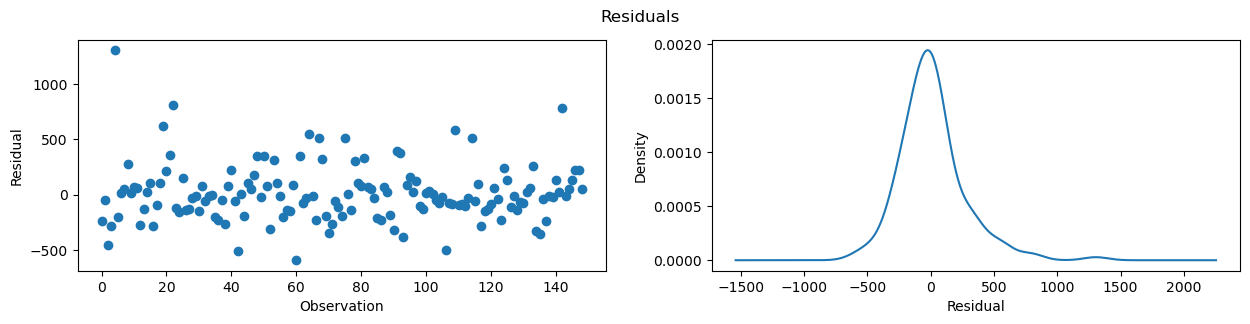

In [16]:
#e) Visualize the residuals using the plot_residuals() function from the ml_utils.regression module.
from ml_utils.regression import plot_residuals
plot_residuals(y_test, y_predict)


### Exercise 3: Classify planets that have shorter years than Earth

a) Using the data/planets.csv file, build a logistic regression model with the eccentricity, semimajor axis, and mass columns as regressors. You will need to make a new column to use for the y (year shorter than Earth). 

b) Find the accuracy score.

c) Use the classification_report() function from scikit-learn to see the precision, recall, and F1 score for each class.

d) With the plot_roc() function from the ml_utils.classification module, plot the ROC curve.

e) Create a confusion matrix using the confusion_matrix_visual() function from the ml_utils.classification module.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from ml_utils.classification import plot_roc, confusion_matrix_visual
planets = pd.read_csv('data/planets.csv')
planets.head()

,mass,description,periastrontime,semimajoraxis,discoveryyear,list,eccentricity,period,discoverymethod,lastupdate,periastron,name
0,19.400,11 Com b is a brown dwarf-mass companion to th...,2452899.60,1.290,2008.0,Confirmed planets,0.231,326.03,RV,15/09/20,94.800,11 Com b
1,11.200,11 Ursae Minoris is a star located in the cons...,2452861.04,1.540,2009.0,Confirmed planets,0.080,516.22,RV,15/09/20,117.630,11 UMi b
2,4.800,14 Andromedae is an evolved star in the conste...,2452861.40,0.830,2008.0,Confirmed planets,0.000,185.84,RV,15/09/20,0.000,14 And b
3,4.975,The star 14 Herculis is only 59 light years aw...,NaN,2.864,2002.0,Confirmed planets,0.359,1766.00,RV,15/09/21,22.230,14 Her b
4,7.679,14 Her c is the second companion in the system...,NaN,9.037,2006.0,Controversial,0.184,9886.00,RV,15/09/21,189.076,14 Her c


In [18]:
#a) Using the data/planets.csv file, build a logistic regression model with the eccentricity, semimajor axis, and mass columns as regressors. 
#You will need to make a new column to use for the y (year shorter than Earth, about 365) 
planets['shorter_than_earth'] =planets.period < 365
#If period is shorter than a year on Earth, 1 else 0.
# defining features x and target y
# x = planets [['eccentricity', 'semimajoraxis', 'mass']]
# y = planets.shorter_than_earth
#dropping the rows with missing values
data = planets[['eccentricity', 'semimajoraxis', 'mass', 'shorter_than_earth']].dropna()
x = data[['eccentricity', 'semimajoraxis', 'mass']]
y = data.shorter_than_earth
planets.head()

,mass,description,periastrontime,semimajoraxis,discoveryyear,list,eccentricity,period,discoverymethod,lastupdate,periastron,name,shorter_than_earth
0,19.400,11 Com b is a brown dwarf-mass companion to th...,2452899.60,1.290,2008.0,Confirmed planets,0.231,326.03,RV,15/09/20,94.800,11 Com b,True
1,11.200,11 Ursae Minoris is a star located in the cons...,2452861.04,1.540,2009.0,Confirmed planets,0.080,516.22,RV,15/09/20,117.630,11 UMi b,False
2,4.800,14 Andromedae is an evolved star in the conste...,2452861.40,0.830,2008.0,Confirmed planets,0.000,185.84,RV,15/09/20,0.000,14 And b,True
3,4.975,The star 14 Herculis is only 59 light years aw...,NaN,2.864,2002.0,Confirmed planets,0.359,1766.00,RV,15/09/21,22.230,14 Her b,False
4,7.679,14 Her c is the second companion in the system...,NaN,9.037,2006.0,Controversial,0.184,9886.00,RV,15/09/21,189.076,14 Her c,False


In [19]:
# train/test split (25% test)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=0, stratify=y)
#Building and fitting the pipeline
pipeline=Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(random_state=0))
]).fit(x_train, y_train)

In [22]:
# b) Find the accuracy score.
accuracy = pipeline.score(x_test, y_test)
print(f"\nAccuracy: {accuracy:.4f}")


Accuracy: 0.9450


Accuracy indicates that the model guesses shorter_than_earth about 94% of the time correctly.

In [20]:
# c) Use the classification_report() function from scikit-learn to see the precision, recall, and F1 score for each class.
y_predict = pipeline.predict(x_test)
print("\nClassification Report:")
print(classification_report(y_test, y_predict))


Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.86      0.91       103
        True       0.94      0.99      0.96       206

    accuracy                           0.94       309
   macro avg       0.95      0.92      0.94       309
weighted avg       0.95      0.94      0.94       309



The model guesses "True," meaning that the year is shorter than the Earth year 94% of the time. It also guesses "False" the year is not shorter than the Earth year 97% of the time.

Recall shows that the model found 99% of the short year planets where as it found only 86% of the long year planets, which is the weak point of this model. 

F1-score combines Precision and Recall into one number. It shows an excellent score for "True" short year - 0.96. The "False" long year is 0.91 which is still very good score. 

Support shows that there are 206 "True" short year planets and only 103 "False" long year planets, which causes the weighted average to be closer to "True" than "False".

<Axes: title={'center': 'ROC curve'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>

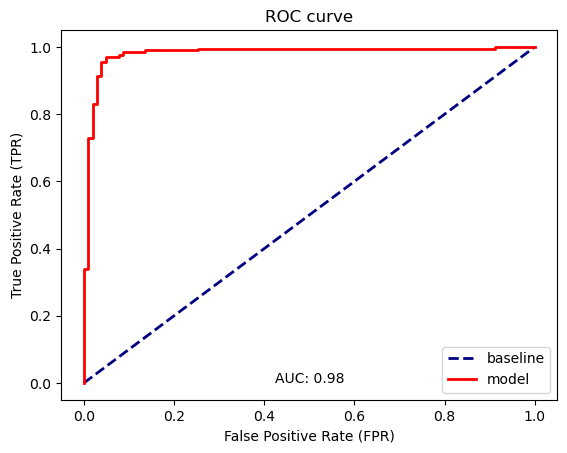

In [21]:
# d) With the plot_roc() function from the ml_utils.classification module, plot the ROC curve.
y_proba = pipeline.predict_proba(x_test)[:,1]
plot_roc(y_test, y_proba)

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Actual', ylabel='Model Prediction'>

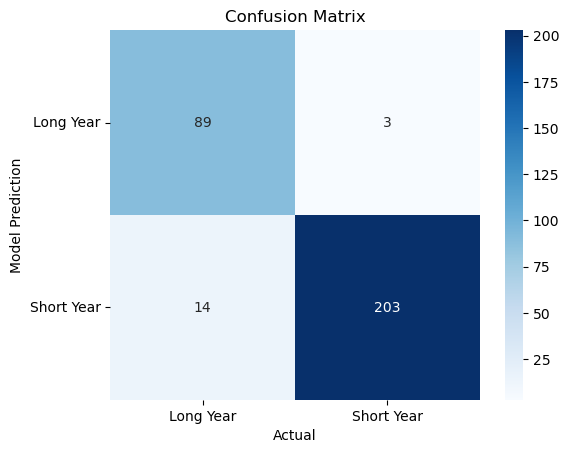

In [22]:
# e) Create a confusion matrix using the confusion_matrix_visual() function from the ml_utils.classification module.
confusion_matrix_visual(y_test, y_predict, class_labels=['Long Year', 'Short Year'])

The model predicted 203 true positives and 89 true negatives. It produced 14 false positives and only 3 false negatives. This shows the model is robust. More short-year planets trained the model rather to guess "True" and be wrong occasionally than miss a short year and have a false negative. 